
# Chapter 8 — Economic Modeling (Part 1a: Planetary energy balance)

Chapter 8 is by far the largest chapter in the book (264 MATLAB scripts —
more than the whole rest of the series combined), covering the physical
science of climate change, integrated assessment/DICE-style
economic-climate models, and environmentally-extended input-output (EEIO)
carbon accounting. It is being built as a long sequence of lettered
notebooks grouped by topic, the same way Chapter 5's biodiversity case
study was split into `05a`-`05f`. See `chapter8_scoping.md` in the project
for the full roadmap and running status.

This first notebook covers `chap8_physic1*.m` and `chap8_physic2*.m` (11
scripts): the basic physics of the Earth's radiative energy balance —
blackbody radiation and the solar spectrum, the effective radiating
temperature of a planet, single- and multi-layer greenhouse models, and
the thermal relaxation time of the ocean-atmosphere system. Every script
here is self-contained first-principles physics with hardcoded physical
constants — no external data files.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

color_red    = np.array([255,  80,  50]) / 255
color_blue   = np.array([  0,  20, 255]) / 255
color_green  = np.array([ 20, 200,  80]) / 255
color_violet = np.array([255,  51, 255]) / 255
color_black  = np.array([0, 0, 0])
color_yellow = np.array([255, 255,   0]) / 255
color_matlab_darkyellow = np.array([0.9290, 0.6940, 0.1250])

def planck_law(wavelength, T):
    # Spectral radiance (W / m^2 / sr / m) of a blackbody at temperature T (K).
    c = 2.99792458e8
    h = 6.62608e-34
    k = 1.38066e-23
    w = h * c / (k * T)
    return (2 * h * c**2) / (wavelength**5) / (np.exp(w / wavelength) - 1)



## 1. The solar constant

`chap8_physic1a.m`. From the Sun's luminosity and the Earth-Sun distance:
the solar constant $S_0$, the Sun's own surface flux, and (via the
Stefan-Boltzmann law) the Sun's effective surface temperature.


In [2]:

d1, d2 = 147.1, 152.1   # perihelion / aphelion distance, Gm
d_mean = (d1 + d2) / 2
print(f"Mean Earth-Sun distance: d = {d_mean:.2f} Gm")

L0 = 3.828e26     # solar luminosity, W
d = 149e9         # mean distance, m
S0 = L0 / (4 * np.pi * d**2)
print(f"Solar constant: S0 = {S0:.2f} W/m^2")

R_sun = 696342e3  # solar radius, m
S_sun = L0 / (4 * np.pi * R_sun**2)
print(f"Solar surface flux: S_sun = {S_sun:.2f} W/m^2")

sigma = 5.67e-8
T_sun = (S_sun / sigma) ** 0.25
print(f"Effective solar surface temperature (blackbody, epsilon=1): T_sun = {T_sun:.2f} K")

epsilon = 0.96
T_sun = (S_sun / (epsilon * sigma)) ** 0.25
print(f"Effective solar surface temperature (epsilon=0.96): T_sun = {T_sun:.2f} K")


Mean Earth-Sun distance: d = 149.60 Gm
Solar constant: S0 = 1372.11 W/m^2
Solar surface flux: S_sun = 62822741.43 W/m^2
Effective solar surface temperature (blackbody, epsilon=1): T_sun = 5769.44 K
Effective solar surface temperature (epsilon=0.96): T_sun = 5828.62 K



## 2. Blackbody spectra

`chap8_physic1b.m`: Planck's law for two blackbody temperatures
(5000 K and 3000 K), with the UV/visible/infrared bands marked.
`chap8_physic1c.m`: the same idea applied to the Sun (5525 K) and the
Earth's surface (288 K) on a log wavelength axis, showing how little the
two spectra overlap — the physical basis of the greenhouse effect.


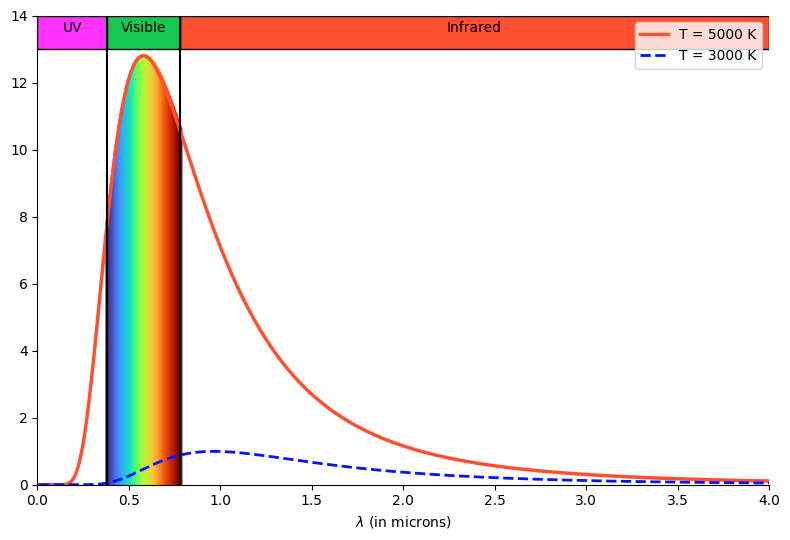

In [3]:

T1, T2 = 5000, 3000
wl = np.linspace(1e-8, 4e-6, 400)
B1 = planck_law(wl, T1)
B2 = planck_law(wl, T2)

lambda_UV, lambda_VIS, lambda_upper = 380e-9, 780e-9, 4e-6

fig, ax = plt.subplots(figsize=(8, 5.5))
cmap = plt.get_cmap("turbo")
x_band = np.linspace(lambda_UV, lambda_VIS, 256)
y_band = planck_law(x_band, T1)
for i in range(256):
    ax.plot([1e6 * x_band[i]] * 2, [0, y_band[i] / 1e12], "-", color=cmap(i / 255), linewidth=2.5)

ax.plot(1e6 * wl, B1 / 1e12, "-", color=color_red, linewidth=2.5, label=f"T = {T1} K")
ax.plot(1e6 * wl, B2 / 1e12, "--", color=color_blue, linewidth=2.0, label=f"T = {T2} K")

band_h = 1.0
for (lo, hi, c) in [(0, lambda_UV, color_violet), (lambda_VIS, lambda_upper, color_red),
                     (lambda_UV, lambda_VIS, color_green)]:
    ax.add_patch(plt.Rectangle((1e6 * lo, 13), 1e6 * (hi - lo), band_h,
                                facecolor=c, edgecolor="black", linewidth=1))
ax.plot([1e6 * lambda_UV] * 2, [0, 14], "-", color="black", linewidth=1.5)
ax.plot([1e6 * lambda_VIS] * 2, [0, 14], "-", color="black", linewidth=1.5)
ax.text(1e6 * lambda_UV / 2, 13.5, "UV", ha="center")
ax.text(1e6 * (lambda_UV + lambda_VIS) / 2, 13.5, "Visible", ha="center")
ax.text(1e6 * (lambda_VIS + lambda_upper) / 2, 13.5, "Infrared", ha="center")

ax.set_xlabel(r"$\lambda$ (in microns)")
ax.legend(loc="upper right")
ax.set_xlim(0, 4)
ax.set_ylim(0, 14)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


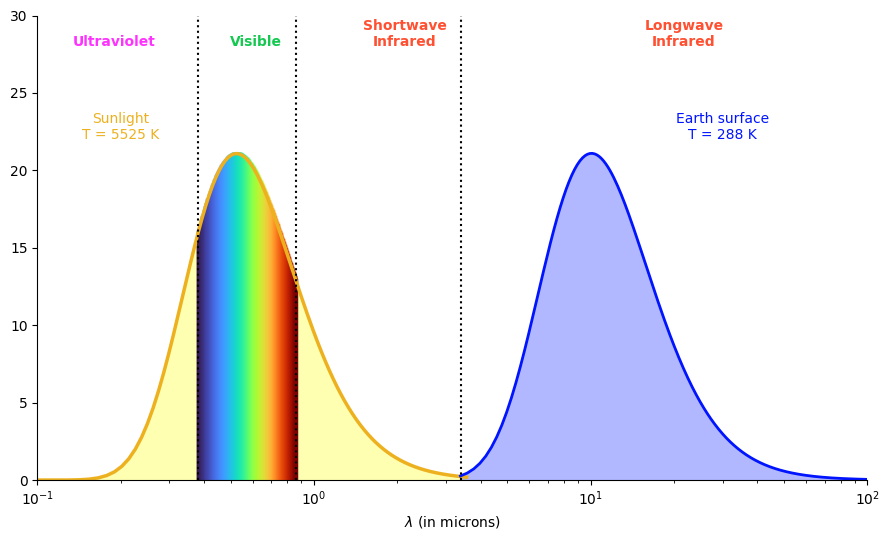

In [4]:

T1, T2 = 5525, 288
lambda1 = np.linspace(1e-8, 6e-6, 500)
lambda2 = np.linspace(1e-6, 1e-4, 500)
lambda_SL = 3.4e-6
lambda1 = lambda1[lambda1 <= 1.05 * lambda_SL]
lambda2 = lambda2[lambda2 >= 0.95 * lambda_SL]
B1 = planck_law(lambda1, T1)
B2 = 2.6e6 * planck_law(lambda2, T2)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(1e6 * lambda1, 0, B1 / 1e12, color=color_yellow, alpha=0.30, edgecolor="none")
ax.fill_between(1e6 * lambda2, 0, B2 / 1e12, color=color_blue, alpha=0.30, edgecolor="none")

lambda_UV, lambda_VIS, lambda_upper = 380e-9, 1.1 * 780e-9, 100e-6
cmap = plt.get_cmap("turbo")
x_band = np.linspace(lambda_UV, lambda_VIS, 256)
y_band = planck_law(x_band, T1)
for i in range(256):
    ax.plot([1e6 * x_band[i]] * 2, [0, y_band[i] / 1e12], "-", color=cmap(i / 255), linewidth=2.5)

ax.plot(1e6 * lambda1, B1 / 1e12, "-", color=color_matlab_darkyellow, linewidth=2.5)
ax.plot(1e6 * lambda2, B2 / 1e12, "-", color=color_blue, linewidth=2.0)

for lam in [lambda_UV, lambda_VIS, lambda_SL]:
    ax.plot([1e6 * lam] * 2, [0, 30], ":", color="black", linewidth=1.5)

h = 28.0
ax.text(1e6 * lambda_UV / 2, h, "Ultraviolet", ha="center", color=color_violet, fontweight="bold")
ax.text(1e6 * (lambda_UV + lambda_VIS) / 2, h, "Visible", ha="center", color=color_green, fontweight="bold")
ax.text(1e6 * (lambda_VIS + lambda_SL) / 2, h, "Shortwave\nInfrared", ha="center", color=color_red, fontweight="bold")
ax.text(1e6 * (lambda_SL + lambda_upper) / 2 - 30, h, "Longwave\nInfrared", ha="center", color=color_red, fontweight="bold")

ax.set_xlabel(r"$\lambda$ (in microns)")
ax.text(0.2, 22, "Sunlight\nT = 5525 K", ha="center", color=color_matlab_darkyellow, fontsize=10)
ax.text(30, 22, "Earth surface\nT = 288 K", ha="center", color=color_blue, fontsize=10)

ax.set_xlim(0.1, 100)
ax.set_xscale("log")
ax.set_ylim(0, 30)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 3. The effective radiating temperature

`chap8_physic1d.m`. Absorbed solar flux per unit area, expressed as an
equivalent number of light bulbs; the Earth's effective (blackbody)
radiating temperature.


In [5]:

S0, alpha_p = 1368, 0.29
F_solar = (1 - alpha_p) * S0 / 4
print(f"Absorbed solar flux: F_solar = {F_solar:.2f} W/m^2")

x = np.array([1, 5, 10, 20, 50, 100])
E = x * F_solar
lamp = 200
N = E / lamp
print(np.round(np.vstack([E, N]), 2))

sigma = 5.67e-8
T_e = ((1 - alpha_p) * S0 / (4 * sigma)) ** 0.25
print(f"T_e = {T_e:.2f} K = {T_e - 273.15:.2f} C")


Absorbed solar flux: F_solar = 242.82 W/m^2
[[2.4282e+02 1.2141e+03 2.4282e+03 4.8564e+03 1.2141e+04 2.4282e+04]
 [1.2100e+00 6.0700e+00 1.2140e+01 2.4280e+01 6.0700e+01 1.2141e+02]]
T_e = 255.81 K = -17.34 C



## 4. The single- and multi-layer greenhouse model

`chap8_physic1e.m` (a single perfectly-absorbing atmospheric layer),
`chap8_physic1f.m` (generalized to three stacked layers), and
`chap8_physic1g.m` (a single layer with tunable emissivity
$\varepsilon \in [0,1]$, solved for the value that reproduces Earth's
actual observed surface temperature).


In [6]:

S0, alpha_p = 1368, 0.29
F_solar = (1 - alpha_p) * S0 / 4
sigma = 5.67e-8
T_e = ((1 - alpha_p) * S0 / (4 * sigma)) ** 0.25

T_a = T_e
T_s = 2 ** 0.25 * T_e
print("Single-layer model, [T_a, T_s] in K:", np.round([T_a, T_s], 2))
print("in C:", np.round([T_a - 273.15, T_s - 273.15], 2))

T_s_obs = 273.15 + 15
gamma_p = 1 - F_solar / (sigma * T_s_obs**4)
print(f"Implied greenhouse factor to match observed T_s = 15C: gamma_p = {gamma_p:.4f}")


Single-layer model, [T_a, T_s] in K: [255.81 304.22]
in C: [-17.34  31.07]
Implied greenhouse factor to match observed T_s = 15C: gamma_p = 0.3788


In [7]:

T_2 = T_e
T_1 = 2 ** 0.25 * T_e
T_s = 3 ** 0.25 * T_e
print("Three-layer model, [T_s, T_1, T_2] in K:", np.round([T_s, T_1, T_2], 2))
print("in C:", np.round([T_s - 273.15, T_1 - 273.15, T_2 - 273.15], 2))


Three-layer model, [T_s, T_1, T_2] in K: [336.67 304.22 255.81]
in C: [ 63.52  31.07 -17.34]


epsilon* = 0.7576, T_a* = 242.30 K = -30.85 C


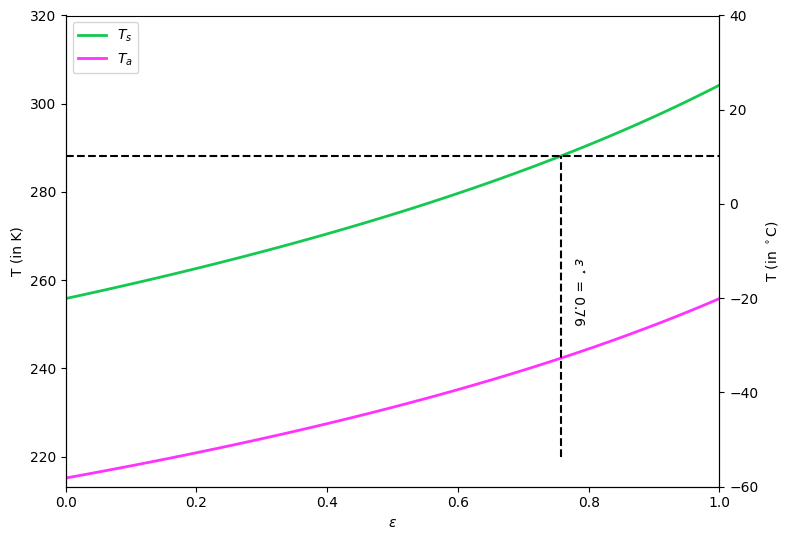

In [8]:

T_a_base = T_e
epsilon = np.arange(0, 1.001, 0.01)
T_s_curve = (2 / (2 - epsilon)) ** 0.25 * T_e
T_a_curve = (1 / (2 - epsilon)) ** 0.25 * T_e

T_s_star = 273.15 + 15
epsilon_star = 2 * (1 - (T_e / T_s_star) ** 4)
T_a_star = (1 / (2 - epsilon_star)) ** 0.25 * T_e
print(f"epsilon* = {epsilon_star:.4f}, T_a* = {T_a_star:.2f} K = {T_a_star - 273.15:.2f} C")

fig, ax1 = plt.subplots(figsize=(8, 5.5))
ax1.plot(epsilon, T_s_curve, "-", color=color_green, linewidth=2.0, label=r"$T_s$")
ax1.plot(epsilon, T_a_curve, "-", color=color_violet, linewidth=2.0, label=r"$T_a$")
ax1.plot([epsilon_star, epsilon_star], [220, T_s_star], "--", color="black", linewidth=1.5)
ax1.plot([0, 1], [T_s_star, T_s_star], "--", color="black", linewidth=1.5)
ax1.set_ylabel("T (in K)")
ax1.set_ylim(273.15 - 60, 273.15 + 40)
ax1.set_yticks(np.arange(220, 321, 20))
ax1.set_xlim(0, 1)
ax1.set_xlabel(r"$\varepsilon$")
ax1.legend(loc="upper left")
ax1.text(epsilon_star + 0.025, 250, rf"$\varepsilon^\star$ = {epsilon_star:.2f}", rotation=-90, ha="center")

ax2 = ax1.twinx()
ax2.set_ylabel(r"T (in $^\circ$C)")
ax2.set_ylim(-60, 40)
ax2.set_yticks(np.arange(-60, 41, 20))

ax1.spines[["top"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 5. Thermal relaxation of the ocean-atmosphere system

`chap8_physic2a.m`: back-of-envelope heat-capacity estimates (atmospheric
mass per unit area from surface pressure, and a scale-height argument).
`chap8_physic2b.m`-`chap8_physic2d.m`: the radiative relaxation time
constant $\tau = mc / (4 \varepsilon \sigma T^3)$ for a linearized
Stefan-Boltzmann radiative damping, and the resulting exponential
temperature-anomaly decay for different reference temperatures and
emissivities.


In [9]:

M, R = 5.148e18, 6371 * 1000
A = 4 * np.pi * R**2
print(f"A = {A / 1e12:.4f} (x1e12 m^2)")
m = M / A
print(f"m (from total atm. mass / area) = {m:.4f} kg/m^2")

Ps, g = 101325, 9.81
m = Ps / g
print(f"m (from surface pressure / g) = {m:.4f} kg/m^2")

h, rho = 8200, 1.225
m = h * rho
print(f"m (from scale height x density) = {m:.4f} kg/m^2")

Delta_E, c = 1000, 4186
Delta_T = Delta_E / c
print(f"Delta_T for 1000 J into 1 kg of water: {Delta_T:.4f} K")


A = 510.0645 (x1e12 m^2)
m (from total atm. mass / area) = 10092.8418 kg/m^2
m (from surface pressure / g) = 10328.7462 kg/m^2
m (from scale height x density) = 10045.0000 kg/m^2
Delta_T for 1000 J into 1 kg of water: 0.2389 K


tau (s): [5562720. 2658427. 1037942.]
tau (days): [64.38 30.77 12.01]


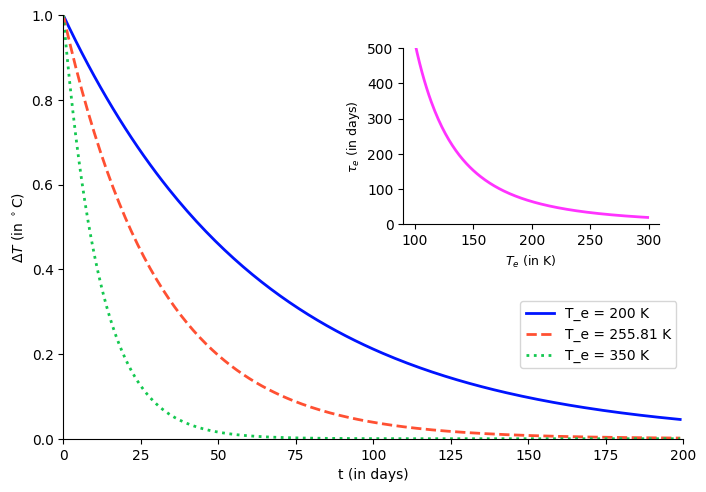

In [10]:

m, c, sigma = 1.0093e4, 1000, 5.67e-8
T_e_vals = np.array([200, 255.81, 350])

tau = (m * c) / (4 * sigma * T_e_vals**3)
print("tau (s):", np.round(tau, 0))
tau_days = tau / (24 * 3600)
print("tau (days):", np.round(tau_days, 2))

t = np.arange(0, 200, 1)
y = np.exp(-t[:, None] / tau_days[None, :])

T_e_range = np.arange(100, 300, 1)
tau_range = (m * c) / (4 * sigma * T_e_range**3) / (24 * 3600)

fig, ax = plt.subplots(figsize=(8, 5.5))
labels = [f"T_e = {T_e_vals[i]:g} K" for i in range(3)]
styles = ["-", "--", ":"]
colors = [color_blue, color_red, color_green]
for i in range(3):
    ax.plot(t, y[:, i], styles[i], color=colors[i], linewidth=2.0, label=labels[i])
ax.set_xlabel("t (in days)")
ax.set_ylabel(r"$\Delta T$ (in $^\circ$C)")
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 0.15))
ax.set_xlim(0, 200)
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)

ax2 = fig.add_axes([0.55, 0.5, 0.32, 0.32])
ax2.plot(T_e_range, tau_range, "-", color=color_violet, linewidth=2.0)
ax2.set_xlabel(r"$T_e$ (in K)", fontsize=9)
ax2.set_ylabel(r"$\tau_e$ (in days)", fontsize=9)
ax2.set_ylim(0, 500)
ax2.spines[["top", "right"]].set_visible(False)

fig.patch.set_facecolor("white")
plt.show()


tau (s): [1969205. 2658427. 3938410.]
tau (days): [22.79 30.77 45.58]


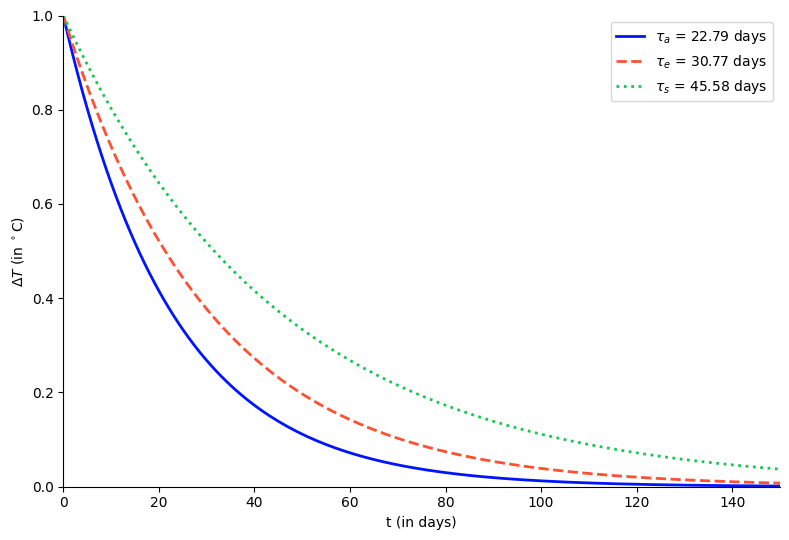

In [11]:

m, c, sigma = 1.0093e4, 1000, 5.67e-8
T_e_vals = np.array([255.81, 255.81, 255.81])
epsilon = 0.65
epsilon_prime = np.array([2 - epsilon, 1, (2 - epsilon) / 2])
tau = (m * c) / (4 * epsilon_prime * sigma * T_e_vals**3)
print("tau (s):", np.round(tau, 0))
tau_days = tau / (24 * 3600)
print("tau (days):", np.round(tau_days, 2))

t = np.arange(0, 200, 1)
y = np.exp(-t[:, None] / tau_days[None, :])

fig, ax = plt.subplots(figsize=(8, 5.5))
letters = ["a", "e", "s"]
styles = ["-", "--", ":"]
colors = [color_blue, color_red, color_green]
for i in range(3):
    ax.plot(t, y[:, i], styles[i], color=colors[i], linewidth=2.0,
            label=rf"$\tau_{letters[i]}$ = {tau_days[i]:.2f} days")
ax.set_xlabel("t (in days)")
ax.set_ylabel(r"$\Delta T$ (in $^\circ$C)")
ax.legend(loc="upper right")
ax.set_xlim(0, 150)
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


In [12]:

m, c, sigma, T = 1.0093e4, 1000, 5.67e-8, 255.81

for epsilon in [1, 0.7]:
    tau = (m * c) / (4 * epsilon * sigma * T**3)
    print(f"epsilon = {epsilon}: tau = {tau:.0f} s = {tau / (24 * 3600):.2f} days")


epsilon = 1: tau = 2658427 s = 30.77 days
epsilon = 0.7: tau = 3797752 s = 43.96 days



## Summary

This notebook covers the 11 `chap8_physic1*.m`/`chap8_physic2*.m`
scripts: blackbody radiation, the Earth's radiative energy balance, and
the ocean-atmosphere thermal relaxation timescale. Purely first-principles
physics with hardcoded constants — no data dependency, and nothing here
looks like a reusable packaging candidate beyond the generic `planck_law`
helper (tracked below, since it is plausibly reused by a later Chapter 8
notebook covering related radiative-transfer material).

Continued in `08b_...` (planned: `chap8_physic3*.m`, atmospheric
composition/CO2).
